In [1]:
import sys
import os
import json
import warnings
import pickle
import importlib
from datetime import date, timedelta, datetime
from itertools import repeat, chain
from functools import partial

import numpy as np
import pandas as pd
import geopandas as gpd
import shap
from matplotlib import pyplot as plt
from geopy.distance import geodesic
import networkx as nx
import IPython

# 调整工作目录及 sys.path
script_directory = IPython.get_ipython().starting_dir
print("Script directory:", script_directory)
sys.path.append(script_directory)

# 默认工作目录为 ipynb 所在目录，这里切换到上一级目录
working_directory = os.path.dirname(script_directory)
os.chdir(working_directory)
print("Current working directory:", os.getcwd())
sys.path.append(working_directory)

# 导入本地模块
import packFuncForShap as pack4shap
import SCBIRL_Global_PE.utils as SIRLU
from SCBIRL_Global_PE.utils import intDate2Date, intDate2TimeX
import mentalMap
import Analysis.utils as AU

# 由于在 Jupyter 中，工作目录改变后可能需要重载模块
importlib.reload(pack4shap)
# importlib.reload(mentalMap)
importlib.reload(AU)

Script directory: /root/cogmap_field/Analysis
Current working directory: /root/cogmap_field


<module 'Analysis.utils' from '/root/cogmap_field/Analysis/utils.py'>

In [ ]:
who = 1102234
who_str = f"{who:09d}"
traj_file_path = os.path.join("data", "user_data_survey", who_str, "all_traj.json")

with open(traj_file_path, "r", encoding="utf-8") as f:
    stay_points_data = json.load(f)

warnings.filterwarnings("ignore")

visit_dates = SIRLU.visited_date(who)
traveler = SIRLU.load_traveler(who)
iter_start_date = traveler.iter_start_date
week_end_dates, _ = SIRLU.extract_week_ends(visit_dates)
week_end_iter_dates = [date for date in week_end_dates if date > iter_start_date]
week_end_iter_dates.insert(0, iter_start_date)

# ✅ 收集所有停留点的坐标
all_lons = []
all_lats = []
for sp in stay_points_data:
    travel_chain = sp["travel_chain"]
    all_lons.extend([pt[0] for pt in travel_chain])
    all_lats.extend([pt[1] for pt in travel_chain])

canvas = []
for date in week_end_iter_dates:
    grids_with_rewards = mentalMap.mentalMap(who, date)
    fig, ax = plt.subplots(figsize=(10, 10))
    grids_with_rewards.plot(ax=ax, column='reward', cmap='coolwarm')

    # ✅ 所有停留点都画上去（灰色背景点）
    ax.scatter(all_lons, all_lats, c='grey', marker='o', s=30, label='All Stay Points', alpha=0.5)

    # ✅ 当前日期的 travel_chain 路径和点用黑色高亮
    for sp in stay_points_data:
        if sp["date"] == date:
            travel_chain = sp["travel_chain"]
            lons = [pt[0] for pt in travel_chain]
            lats = [pt[1] for pt in travel_chain]

            ax.scatter(lons, lats, c='black', marker='o', s=50, label='Today\'s Points')

            G = nx.DiGraph()
            for i, pt in enumerate(travel_chain):
                G.add_node(i, pos=(pt[0], pt[1]))
            for i in range(len(travel_chain) - 1):
                G.add_edge(i, i + 1)

            pos = nx.get_node_attributes(G, 'pos')
            nx.draw_networkx_edges(
                G, pos=pos, ax=ax, arrows=True, arrowstyle='-|>',
                edge_color='black', connectionstyle='arc3,rad=0.1'
            )

    ax.set_title(f"Mental map of person {who} at {date}")
    ax.legend()
    canvas.append(fig)
    plt.show()

## Calculate the mental map

In [3]:
from dask.distributed import Client, LocalCluster
import dask

In [4]:
# select valid weekend to visualize mental map.
def mental_map_vis(who: int):
    # ref: set the warning
    warnings.filterwarnings("ignore")
    visit_dates = SIRLU.visited_date(who)
    traveler = SIRLU.load_traveler(who)
    iter_start_date = traveler.iter_start_date
    week_end_dates, _ = SIRLU.extract_week_ends(visit_dates)
    week_end_iter_dates = [date for date in week_end_dates if date > iter_start_date]
    week_end_iter_dates.insert(0, iter_start_date)
    canvas = []
    for date in week_end_iter_dates:
        grids_with_rewards = mentalMap.mentalMap(who, date)
        fig, ax = plt.subplots(figsize=(10, 10))
        grids_with_rewards.plot(ax=ax, column='reward', cmap='coolwarm')
        ax.set_title(f"Mental map of person {who} at {date}")
        canvas.append(fig)
    # open the warning
    warnings.filterwarnings("default")
    AU.figureList2gif(canvas, f'./product/visualization/mental_map_{who:09d}.gif', fps=0.5) 
    return canvas

In [5]:
def setup_dask_cluster(n_workers=6, threads_per_worker=2, memory_limit="20GB"):
    """
    设置 Dask 本地集群
    :param n_workers: Worker 数量
    :param threads_per_worker: 每个 Worker 的线程数
    :param memory_limit: 每个 Worker 的内存限制
    :return: Dask Client 对象
    """
    cluster = LocalCluster(
        n_workers=n_workers,
        threads_per_worker=threads_per_worker,
        memory_limit=memory_limit
    )
    client = Client(cluster)
    print(f"Dask Dashboard: {client.dashboard_link}")
    return cluster, client

who_list = [68058890, 10013454, 58272403,
             6945721, 71209087, 93854949,
            82455786, 58124481, 54636959,
            25679537,102181433]  # Limit to 10 travelers for testing

try:
    cluster, client = setup_dask_cluster(n_workers=len(who_list))
    mental_map_vis_parallel = dask.delayed(mental_map_vis)
    tasks = [mental_map_vis_parallel(who) for who in who_list]
    results = dask.compute(*tasks)
except Exception as e:
    print(f"Error occurred: {e}")
finally:
    if 'cluster' in locals():
        cluster.close()
    if 'client' in locals():
        client.close()

Dask Dashboard: http://127.0.0.1:8787/status
(49, 3, 2, 10) (49, 3, 2, 1) (49, 3, 2, 2)
(30, 4, 2, 10) (30, 4, 2, 1) (30, 4, 2, 2)
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
(36, 4, 2, 10) (36, 4, 2, 1) (36, 4, 2, 2)
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
(49, 7, 2, 10) (49, 7, 2, 1) (49, 7, 2, 2)
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/010013454/evolution_model/iterated_model_20231030.pickle!
load params from ./model/093854949/evolution_model/iterated_model_20230816.pickle!
load params from ./model/054636959/evolution_model/iterated_model_20230419.pickle!
load params from ./model/068058890/evolution_model/iterated_model_20230426.pickle!
load params from ./model/025679537/evolution_model/iterated_model_20230423.pickle!
load params from ./model/006945721/evolution_model/iterated_model_2

/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/058272403/evolution_model/iterated_model_20230827.pickle!
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
load params from ./model/093854949/evolution_model/iterated_model_20231029.pickle!
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
load params from ./model/058124481/evolution_model/iterated_model_20230702.pickle!
(49, 3, 2, 10) (49, 3, 2, 1) (49, 3, 2, 2)
load params from ./model/068058890/evolution_model/iterated_model_20230709.pickle!
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
load params from ./model/025679537/evolution_model/iterated_model_20230723.pickle!
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/071209087/evolution_model/iterated_model_20230702.pickle!
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/082455786/evolution_model/iterated_model_20230708.pickle!
(49, 7, 2, 10) (49, 7, 2, 1) (49, 7, 2, 2)
load params from ./model/006945721/evolution_model/iterated_model_20230702.

/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/058272403/evolution_model/iterated_model_20230906.pickle!
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
load params from ./model/093854949/evolution_model/iterated_model_20231108.pickle!
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
load params from ./model/058124481/evolution_model/iterated_model_20230716.pickle!
(49, 3, 2, 10) (49, 3, 2, 1) (49, 3, 2, 2)
load params from ./model/068058890/evolution_model/iterated_model_20230722.pickle!
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
load params from ./model/025679537/evolution_model/iterated_model_20230813.pickle!
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/071209087/evolution_model/iterated_model_20230716.pickle!
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/054636959/evolution_model/iterated_model_20230716.pickle!
load params from ./model/082455786/evolution_model/iterated_model_20230721.

...

/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/082455786/evolution_model/iterated_model_20231230.pickle!
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
load params from ./model/054636959/evolution_model/iterated_model_20231224.pickle!
(49, 7, 2, 10) (49, 7, 2, 1) (49, 7, 2, 2)
load params from ./model/006945721/evolution_model/iterated_model_20231224.pickle!
(49, 6, 2, 10) (49, 6, 2, 1) (49, 6, 2, 2)
load params from ./model/058124481/evolution_model/iterated_model_20231231.pickle!
(49, 5, 2, 10) (49, 5, 2, 1) (49, 5, 2, 2)
load params from ./model/071209087/evolution_model/iterated_model_20231231.pickle!
(49, 2, 2, 10) (49, 2, 2, 1) (49, 2, 2, 2)
load params from ./model/054636959/evolution_model/iterated_model_20231231.pickle!


/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


(49, 7, 2, 10) (49, 7, 2, 1) (49, 7, 2, 2)
load params from ./model/006945721/evolution_model/iterated_model_20231231.pickle!


/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/root/miniconda3/envs/basi_geoneuro/lib/python3.12/site-packages/imageio/plugins/pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warning

## Explainable Analysis: Built Environmental Attributes vs Location

In [2]:
def processShapRes(who: int):
    with open(f'./product/shap_res_{who:09d}.pkl', 'rb') as f:
        res = pickle.load(f)
    return res

In [3]:
model_path = './model/'
who_list = [file for file in os.listdir(model_path) if file.isdigit()]

In [4]:
shap_files_list = ['shap_res_' + file + '.pkl' for file in who_list]
shap_res_lst = []
for file in shap_files_list:
    with open('./product/' + file, 'rb') as f:
        shap_res_lst.append(pickle.load(f))

In [5]:
def processReward(who: int):
    reward_res_path = './product/reward_res.pkl'
    with open(reward_res_path, 'rb') as f:
        reward_res = pickle.load(f)
    
    reward_res_filter = filter(lambda x: x[0] == who, reward_res)
    reward_baseline = {key[1]: reward_res[key] for key in sorted(reward_res_filter)}
    r_baseline = np.asarray(list(reward_baseline.values()))
    return r_baseline

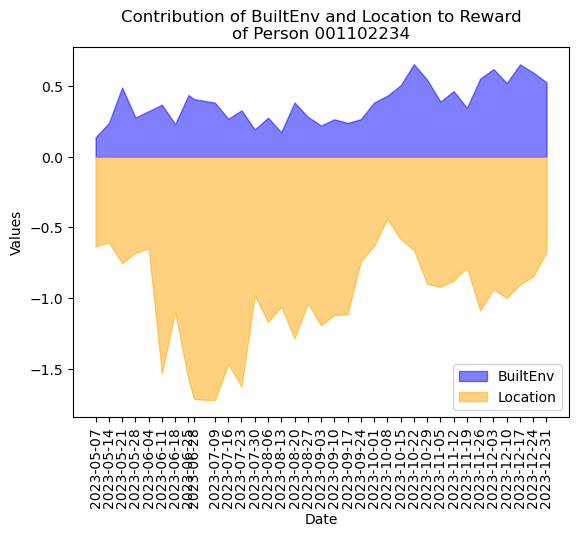

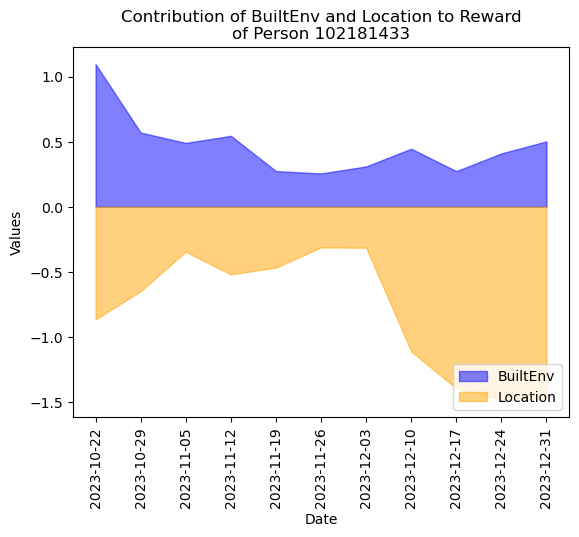

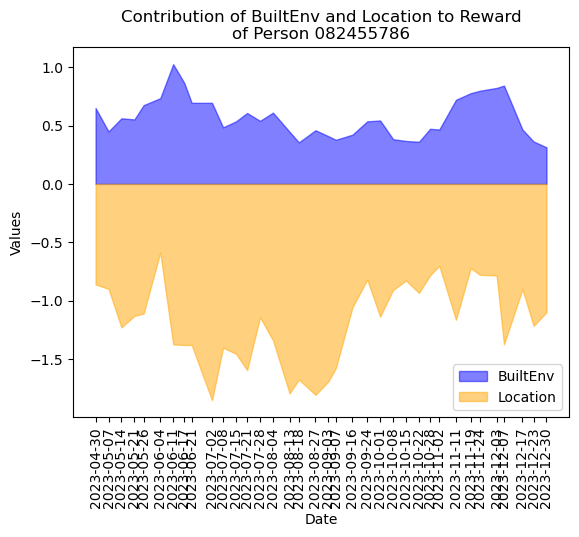

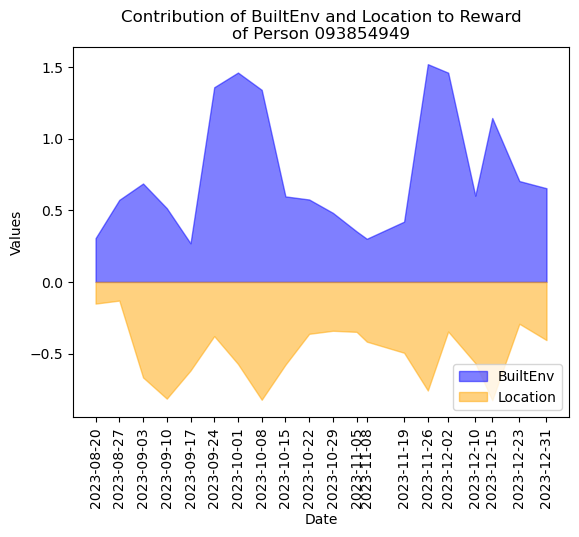

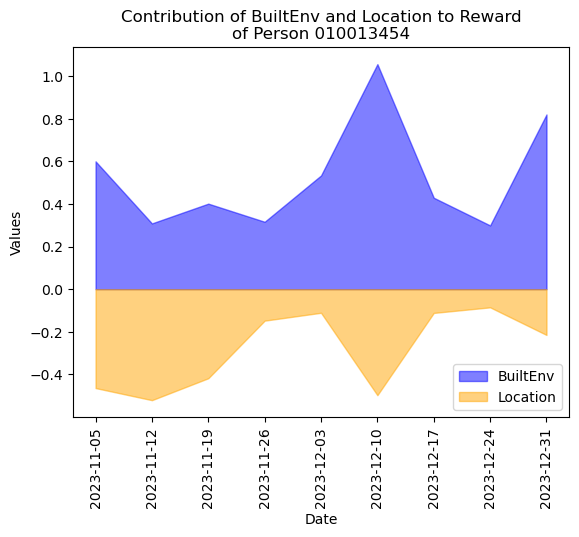

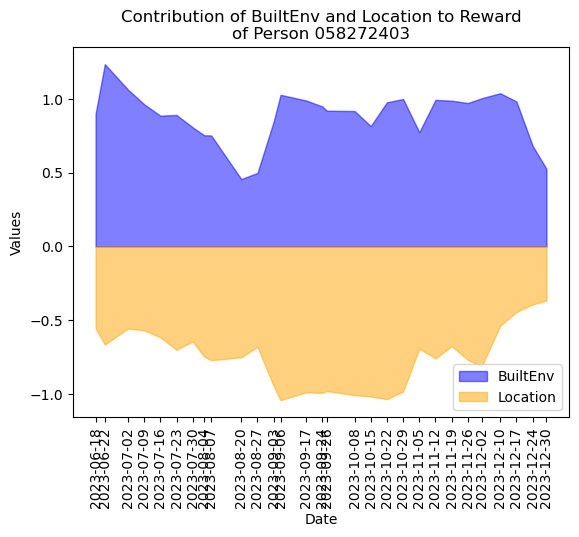

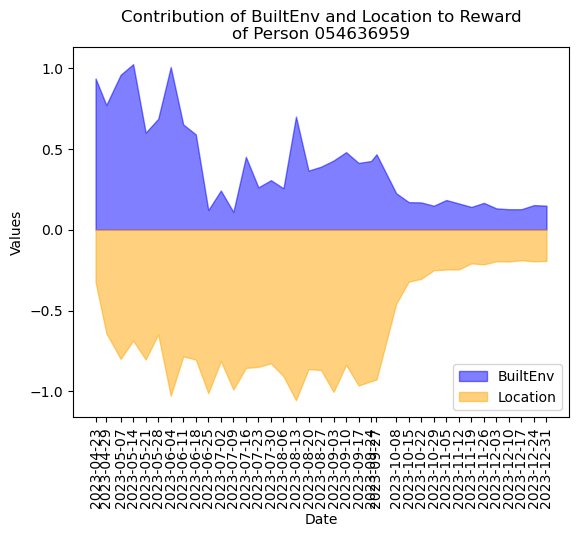

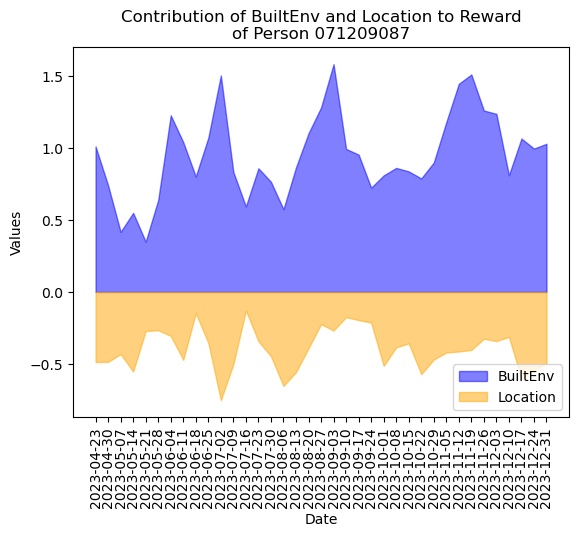

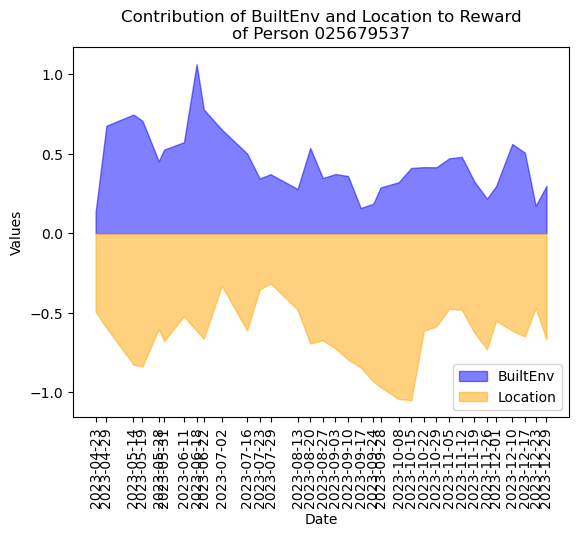

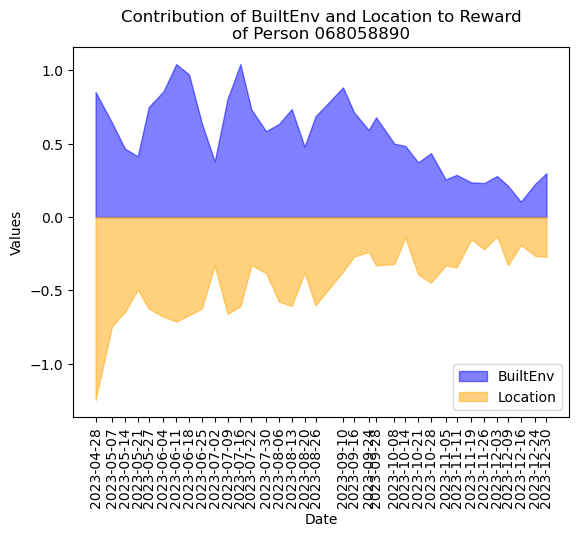

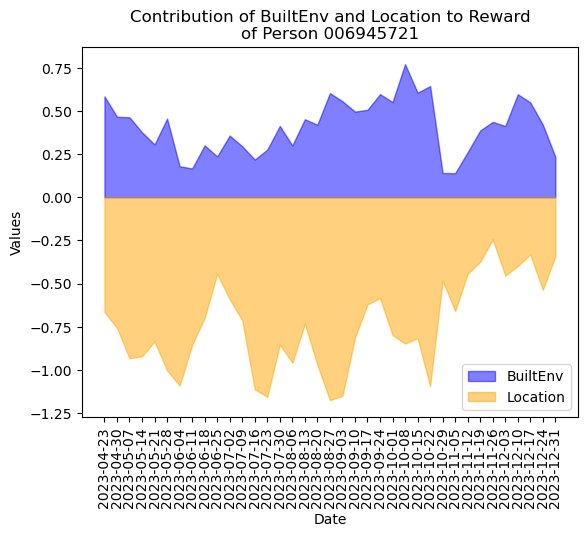

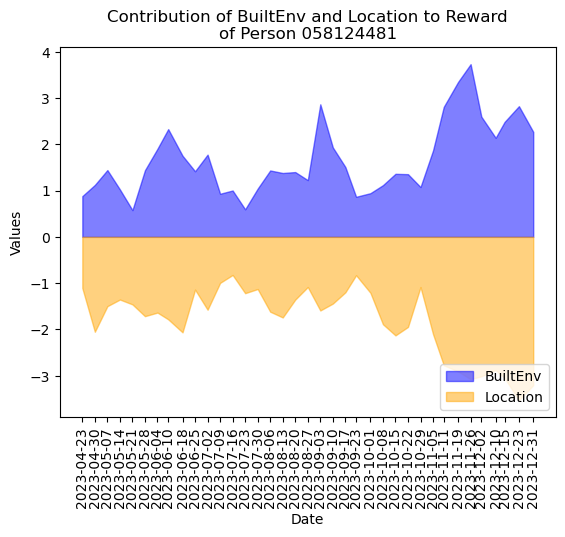

In [6]:
def drawSHAPBuiltPosition(who: int):
    shap_res_one = processShapRes(who)
    date_list = list(shap_res_one.keys())
    date_list.sort()
    r_baseline = processReward(who)         
    varchr = 'LU_Business,LU_Green,LU_Industry,LU_Public,LU_Residence,subway,density,intersections,road_density,rent'
    varname_BE = varchr.split(',')
    groupmap = {
            'BuiltAttr': varname_BE,
            'Location': ['Location']
        }
    
    date_shap_add = {}
    date_weight = {}
    for date, shap_res_tuple in shap_res_one.items():
        shap_res_df, freq_weight, _ = shap_res_tuple
        shap_grouped_by_classes = pack4shap.grouped_shap(shap_vals=shap_res_df.values, features=shap_res_df.columns, groups=groupmap)
        
        date_shap_add[date] = shap_grouped_by_classes
        date_weight[date] = freq_weight

    be_contrib = []
    pe_contrib = []
    for dt in date_list:
        shap_slice = date_shap_add[dt]
        weights = date_weight[dt]
        be_elem = np.average(np.abs(shap_slice['BuiltAttr'].to_numpy()), weights=weights)
        be_contrib.append(be_elem)
        pe_elem = np.average(np.abs(shap_slice['Location'].to_numpy()), weights=weights)
        pe_contrib.append(pe_elem)
    x = [intDate2TimeX(dt) for dt in date_list]
    
    # 创建图形和轴
    fig, ax = plt.subplots()
    y1 = np.array(be_contrib)
    y2 = np.array(pe_contrib)
    # 绘制堆叠区域
    ax.fill_between(x, y1, color='b', alpha=0.5, label='BuiltEnv')  # 蓝色区域, 代表建成环境的贡献, 位于坐标轴上
    ax.fill_between(x, -y2, color='orange', alpha=0.5, label='Location')  # 橙色区域，代表位置的贡献, 位于坐标轴下

    # 设置图例
    ax.legend(loc='lower right')

    # 设置图表标题和坐标轴标签
    ax.set_title('Contribution of BuiltEnv and Location to Reward\nof Person {who:09d}'.format(who=who))
    ax.set_xlabel('Date')
    ax.set_ylabel('Values')
    
    # ax_r = ax.twinx()  # 创建第二个坐标轴
    # ax_r.plot(x, r_baseline, color='darkred', ls='-', marker='o', ms=4, label='Reward')
    # ax_r.set_ylabel('Reward')
    # ax_r.legend(loc='lower left')
    # # 将右侧y轴的范围设置为与左侧y轴相同
    # ax_r.set_ylim([0, 1])

    # 将横坐标的标签设置为日期datelist
    ax.set_xticks(x)
    ax.set_xticklabels([intDate2Date(dt).strftime('%Y-%m-%d') for dt in date_list], rotation=90)

    save_path = './product/visualization/person_{who:09d}_interp.png'.format(who=who)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    plt.savefig(save_path)
    plt.show()

shap_vis = [drawSHAPBuiltPosition(int(who)) for who in who_list]
# drawSHAPBuiltPosition(1102234)

In [ ]:
def drawSHAPSummary(who: int):
    shap_res_one = processShapRes(who)
    date_list = list(shap_res_one.keys())
    date_list.sort()
    target_date = date_list[-1]
    
    shap_res_df, freq_weight, visited_id = shap_res_one[target_date]
    varchr = 'LU_Business,LU_Green,LU_Industry,LU_Public,LU_Residence,subway,density,intersections,road_density,rent'
    varname_BE = varchr.split(',')
    varname = varname_BE + ['Location']
    # replace the `LU` string into 'landuse' the varname list
    varname = [var.replace('LU', 'landuse').capitalize() for var in varname]   

    # find the feature set with visited id
    path = './data/city_grid_features/city_grid_features.geojson'
    city_grid_with_LU = gpd.read_file(path)
    city_grid_only_features = pd.DataFrame(city_grid_with_LU.drop(columns=['geometry', 'chess_x', 'chess_y']))
    visited_fnid = [SIRLU.fniidMapper(who, id) for id in visited_id]
    visited_features = city_grid_only_features.set_index('fnid').loc[visited_fnid]
    
    # compute the distance
    id2coords = SIRLU.load_id_coords_mapping(who)
    visited_coords = [id2coords[id] for id in visited_id]
    visited_coords = np.array(visited_coords) # shape: (n, 2)
    geocenter = np.average(visited_coords, weights=freq_weight, axis=0)
    wrap = lambda x: (x[1], x[0])
    distance = [geodesic(wrap(coord), wrap(geocenter)).kilometers for coord in visited_coords]
    visited_features['distance'] = distance
    
    # conbine 
    drop_cols = ['Position']
    shap_res_df = shap_res_df.drop(columns=[col for col in drop_cols if col in shap_res_df.columns])  
    shap.summary_plot(shap_res_df.values, features=visited_features.values, feature_names=varname, plot_type="dot")

In [ ]:
shap_vis = [drawSHAPSummary(int(who)) for who in who_list]

In [ ]:
with open('./product/iterationEvo_TOTAL.pkl', 'rb') as f:
    intepret_res = pickle.load(f)


In [ ]:
intepret_res

In [ ]:
who_list.sort()
def drawKnowledgeInterpretation(i: int):
    df_eval = intepret_res[i]
    user_code = who_list[i]

    # 创建图形和轴
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 6))

    x = [intDate2TimeX(dt) for dt in df_eval.date]
    yl1 = df_eval.re_contrib.values
    yl2 = df_eval.exp_contrib.values

    yr1 = df_eval.pr_contrib.values
    yr2 = df_eval.acu_contrib.values

    # 绘制堆叠区域
    ax_l.plot(x, yl1, color='pink', marker='o', ms=2, label='Recent Knowledge')  # 粉色区域在上, 为知识作用
    ax_l.plot(x, yl2, color='gold', marker='o', ms=2, label='Recent Experience')  # 金色区域在下, 为经验作用

    # 设置图例
    ax_l.legend(loc='upper left')

    # 设置图表标题和坐标轴标签
    ax_l.set_title('Contribution of Recent Knowledge and Experience\nto Place Understanding of User {who}'.format(who=user_code))
    ax_l.set_xlabel('Timeline')
    ax_l.set_ylabel('Values')

    # 将横坐标的标签设置为日期datelist
    ax_l.set_xticks(x[::10])
    labels = [intDate2Date(dt).strftime('%Y-%m-%d') for dt in df_eval.date]
    ax_l.set_xticklabels(labels[::10], rotation=90)

    # 绘制堆叠区域
    ax_r.plot(x, yr1, color='pink', marker='o', ms=2, label='Prior Knowledge')  # 粉色区域在上, 为知识作用
    ax_r.plot(x, yr2, color='gold', marker='o', ms=2, label='Accumulate Experience')  # 金色区域在下, 为经验作用

    # 设置图例
    ax_r.legend(loc='upper left')

    # 设置图表标题和坐标轴标签
    ax_r.set_title('Contribution of Prior Knowledge and Accumulative Experience\nto Place Understanding of User {who}'.format(who=user_code))
    ax_r.set_xlabel('Timeline')
    ax_r.set_ylabel('Values')

    # 将横坐标的标签设置为日期datelist
    ax_r.set_xticks(x[::10])
    ax_r.set_xticklabels(labels[::10], rotation=90)

    plt.savefig('./product/visualization/person_{who:09d}_knowledge.png'.format(who=int(user_code)))
    # 显示图表
    plt.show()
    
for i in range(len(who_list)):
    drawKnowledgeInterpretation(i)

In [ ]:
shap.summary_plot(shap_groups[0].values, features=shap_groups[0].columns)

## The relationship between geographic distance and positional encoding

### Absolute encoding

In [12]:
from Analysis.gridDistance import load_user_coordinates

coords_list, all_coords_array = load_user_coordinates()


加载用户坐标数据...


100%|██████████| 20/20 [00:00<00:00, 3825.70it/s]

共加载 20 个用户，总计 2039 个唯一坐标


In [72]:
import importlib
import Analysis.gridDistance as gridDistance
importlib.reload(gridDistance)

<module 'Analysis.gridDistance' from 'e:\\Programming\\Python\\project_GeoNeuro\\project_moires\\spatial_cognition_moire\\Analysis\\gridDistance.py'>

In [ ]:
# random select 1000 coordinates from the all_coords_array
random_indices = np.random.choice(all_coords_array.shape[0], 1000, replace=False)
selected_coords = all_coords_array[random_indices]

geo_dist = gridDistance.calculate_geographic_distance(selected_coords)
geo_dist = np.triu(geo_dist, k=1)

_, abspos_dist = gridDistance.calculate_absolute_encoding_distance(selected_coords)
abspos_dist = np.triu(abspos_dist, k=1)


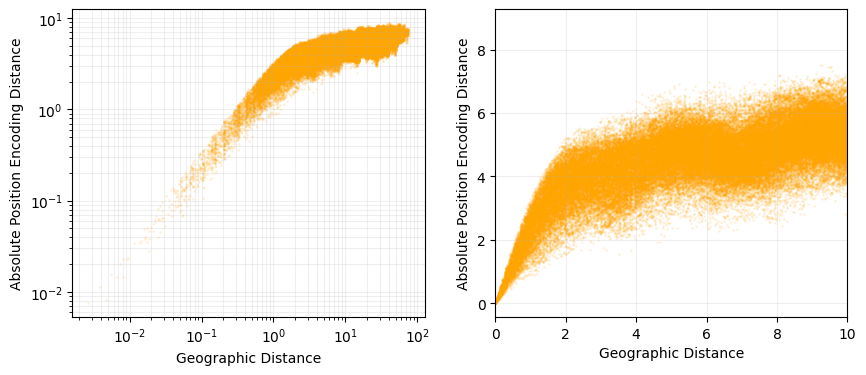

In [50]:
# plot the scatter plot of geo_dist and abspos_dist, with transparency
plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
# select the first subplot
ax = plt.subplot(1, 2, 1)
plt.scatter(geo_dist, abspos_dist, s=1, color='orange', alpha=0.1)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Geographic Distance')
plt.ylabel('Absolute Position Encoding Distance')

ax = plt.subplot(1, 2, 2)
plt.scatter(geo_dist, abspos_dist, s=1, color='orange', alpha=0.1)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(0, 10)
plt.xlabel('Geographic Distance')
plt.ylabel('Absolute Position Encoding Distance')
plt.show()


### Rotationary encoding

In [119]:
import importlib
import Analysis.gridDistance as gridDistance
importlib.reload(gridDistance)

<module 'Analysis.gridDistance' from 'e:\\Programming\\Python\\project_GeoNeuro\\project_moires\\spatial_cognition_moire\\Analysis\\gridDistance.py'>

In [120]:
output, rotpos_dist, embeddings = gridDistance.calculate_relative_encoding_distance(selected_coords)
rotpos_dist = np.triu(rotpos_dist, k=1)

计算相对位置编码距离...


In [121]:
mean1 = np.array(output[:, 0][None, :])
stddev1 = np.array(np.exp(output[:, 1][None, :]))
mean2 = mean1.T
stddev2 = stddev1.T

kl = np.log(stddev2 / stddev1) + ((stddev1 ** 2 + (mean1 - mean2) ** 2) / (2 * stddev2 ** 2)) - 0.5
js = 0.5 * (kl + kl.T)

In [123]:
js_vec = np.triu(js, k=1)


In [124]:
attention_weights = attention_weights.squeeze()
attention_weights = np.triu(attention_weights, k=1)

In [97]:
embeddings = embeddings.squeeze()
inner_product = np.matmul(embeddings, embeddings.T)
inner_product = np.triu(inner_product, k=1)

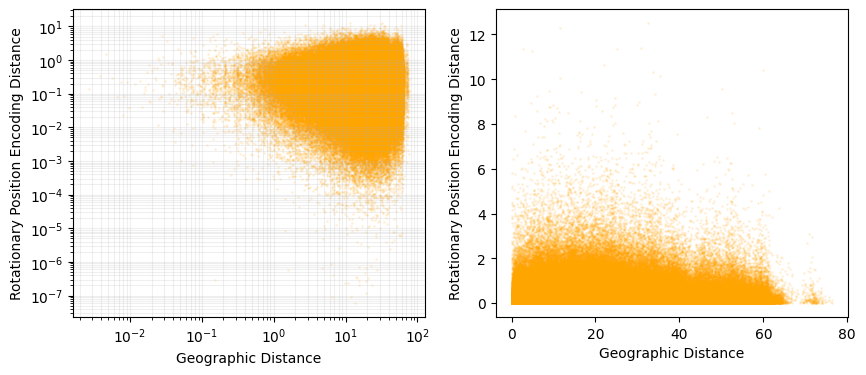

In [125]:
# plot the scatter plot of geo_dist and abspos_dist, with transparency
plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
# select the first subplot
ax = plt.subplot(1, 2, 1)
plt.scatter(geo_dist, js_vec, s=1, color='orange', alpha=0.1)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Geographic Distance')
plt.ylabel('Rotationary Position Encoding Distance')

ax = plt.subplot(1, 2, 2)
plt.scatter(geo_dist, js_vec, s=1, color='orange', alpha=0.1)
plt.xlabel('Geographic Distance')
plt.ylabel('Rotationary Position Encoding Distance')
plt.show()

Test on one user